# **Royal Draconic Conservatory | Regression Project**
**Mivuyo Mpepo**: 2562730

**Nnoso Mokhethi**: 2432900

**Jordan Tshibumbu**: 2453146

**Okwukwechukwu Mbajiorgu**: 2430639

# Introduction

This project investigates the prediction of Flame Heat Output (FHO) using observable dragon characteristics, including wingspan, mass, age, sustained flight speed, hide thickness, and species. The aim is to build and compare regression models that can explain variation in FHO and identify which dragon features are most informative. The notebook begins with data cleaning and exploratory data analysis to examine data quality, variable distributions, outliers, correlations, and relationships with FHO. Single-variable regression models are then fitted for AGE, MASS, WSP, and SPC, followed by multiple regression models using different feature combinations. The models are compared using training and test (R^2), RMSE, and evidence of overfitting. The coefficients of the preferred raw model are interpreted to identify the most influential predictors, while residual plots and error analysis are used to assess reliability and generalisation. Finally, feature engineering is applied through logarithmic and square-root transformations, interaction terms, and physical-size proxies to determine whether the predictive performance can be improved.


# Setup & Data Loading

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})

PALETTE = {"Dragon": "#c0392b", "Wyvern": "#2980b9", "Hydra": "#27ae60"}

df_raw = pd.read_csv("dragon_data (1).csv")
print(f"Shape: {df_raw.shape}")
df_raw.head()

Shape: (500, 7)


,SPC,AGE,MASS,WSP,HID,SPD,FHO
0,Wyvern,16,1304,4.0,4.83,4800,611
1,Dragon,2726,3693174,52.0,4.82,114400,1960
2,Dragon,377,154201,19.4,4.61,42680,1123
3,Hydra,169,40146,13.0,2.65,7800,706
4,Dragon,1571,1549315,39.6,1.49,87120,1441


# Data Processing and Cleaning

In [4]:
print("=== Dtypes ===")
print(df_raw.dtypes)
print()
print("=== Null values ===")
print(df_raw.isnull().sum())
print()
print("=== Species counts (raw) ===")
print(df_raw["SPC"].value_counts())
print()
print("=== Negative numeric values ===")
num = df_raw.select_dtypes(include="number")
print((num < 0).sum())

=== Dtypes ===
SPC         str
AGE       int64
MASS      int64
WSP     float64
HID     float64
SPD       int64
FHO       int64
dtype: object

=== Null values ===
SPC     0
AGE     0
MASS    0
WSP     0
HID     0
SPD     0
FHO     0
dtype: int64

=== Species counts (raw) ===
SPC
Hydra      214
Wyvern     183
Dragon     102
Wyvernn      1
Name: count, dtype: int64

=== Negative numeric values ===
AGE     1
MASS    0
WSP     0
HID     0
SPD     0
FHO     0
dtype: int64


In [5]:
# Show the problematic rows
print("Negative AGE rows:")
print(df_raw[df_raw["AGE"] < 0])
print()
print("Typo species row:")
print(df_raw[~df_raw["SPC"].isin(["Dragon", "Wyvern", "Hydra"])])

Negative AGE rows:
        SPC  AGE    MASS   WSP  HID    SPD   FHO
328  Wyvern -481  223733  21.9  1.4  26280  1276

Typo species row:
         SPC   AGE    MASS   WSP   HID    SPD   FHO
228  Wyvernn  1229  745342  35.0  4.54  42000  1083


In [6]:
# Clean: fix typo, drop negative age
df = df_raw.copy()
df["SPC"] = df["SPC"].replace({"Wyvernn": "Wyvern"})
df = df[df["AGE"] >= 0].reset_index(drop=True)

print(f"Cleaned shape: {df.shape}")
print(df["SPC"].value_counts())

Cleaned shape: (499, 7)
SPC
Hydra     214
Wyvern    183
Dragon    102
Name: count, dtype: int64


Wyvernn was corrected to Wyvern.
The row with negative AGE was removed because age cannot be negative.

# Exploratory Data Analysis

## Univariate Distributions

For each numeric variable we plot:
- A **histogram** to see the overall shape
- A **KDE** overlay to judge skewness
- A **log-scale histogram** where relevant to check if a log transform helps


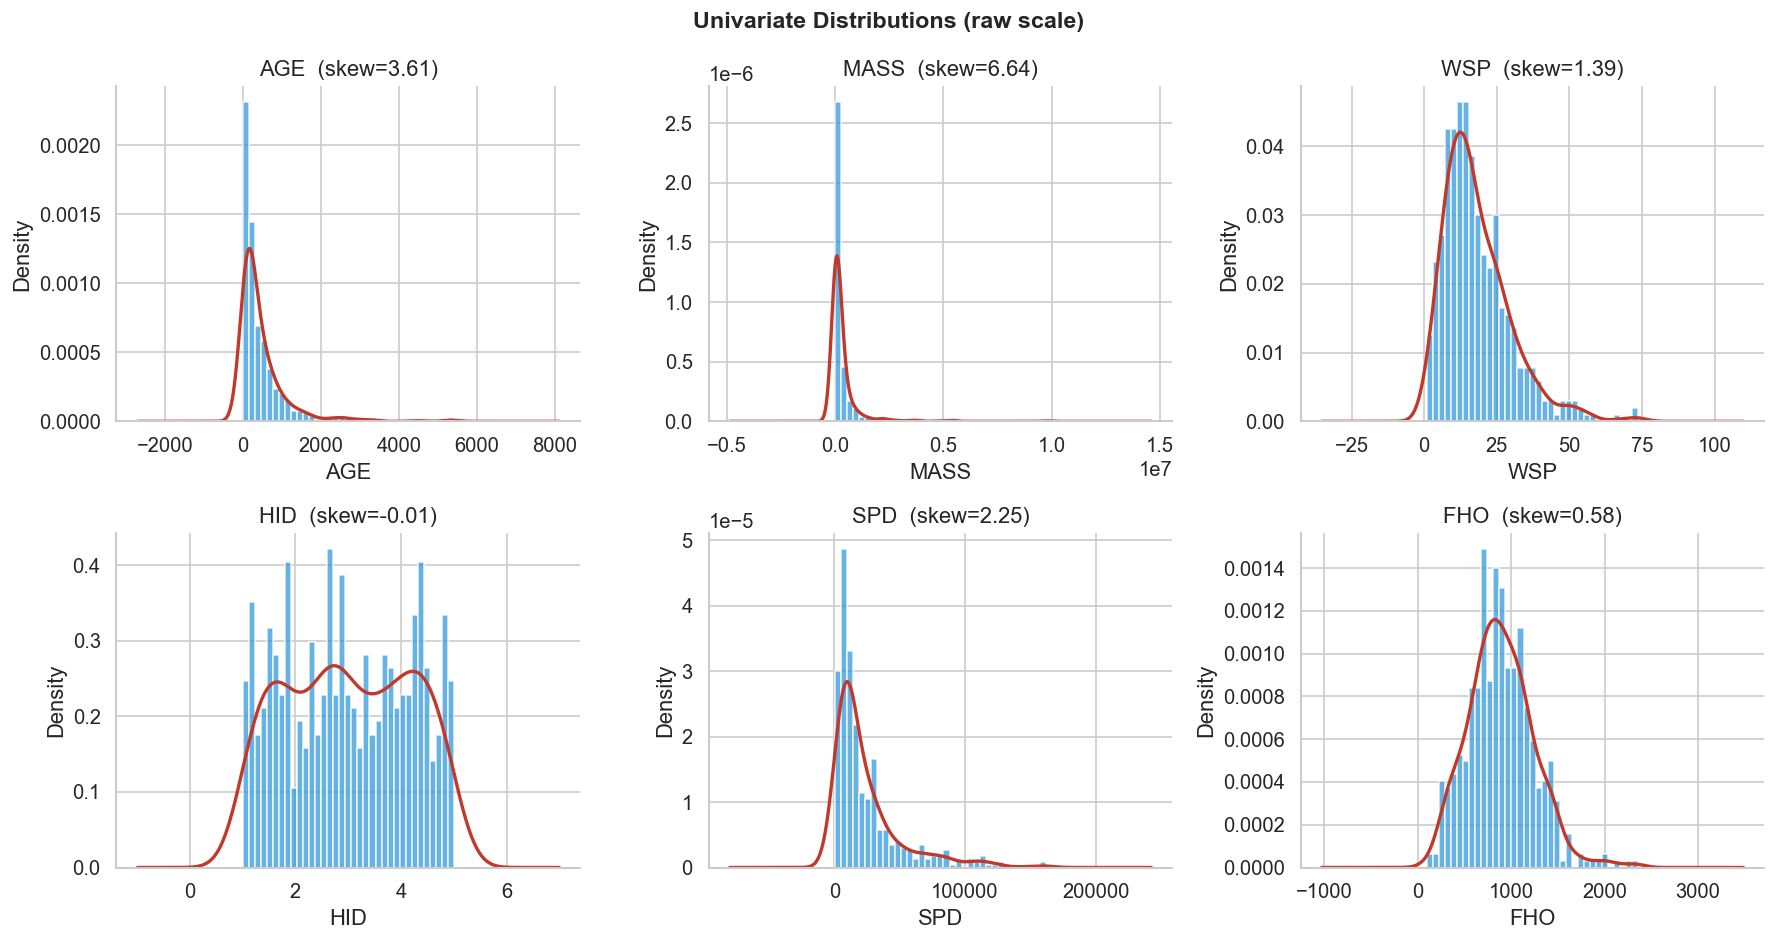

In [7]:
num_cols = ["AGE", "MASS", "WSP", "HID", "SPD", "FHO"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("Univariate Distributions (raw scale)", fontsize=14, fontweight="bold")

for ax, col in zip(axes.flat, num_cols):
    ax.hist(df[col], bins=35, color="#3498db", alpha=0.75, edgecolor="white", density=True)
    df[col].plot.kde(ax=ax, color="#c0392b", lw=2)
    skew = df[col].skew()
    ax.set_title(f"{col}  (skew={skew:.2f})")
    ax.set_xlabel(col)
    ax.set_ylabel("Density")

plt.tight_layout()
plt.show()

In [8]:
# Summary statistics
df[num_cols].describe().round(2)

,AGE,MASS,WSP,HID,SPD,FHO
count,499.00,499.00,499.00,499.00,499.00,499.00
mean,463.36,309420.06,18.19,3.00,24152.87,893.48
std,642.51,752468.43,11.51,1.17,26595.34,350.41
min,1.00,17.00,1.00,1.01,600.00,100.00
25%,107.50,19237.50,10.40,1.92,7650.00,664.00
50%,242.00,79404.00,15.60,2.94,13860.00,869.00
75%,586.00,282925.00,24.20,4.04,29580.00,1107.00
max,5407.00,9729833.00,73.60,5.00,161920.00,2358.00


## Target Variable: FHO

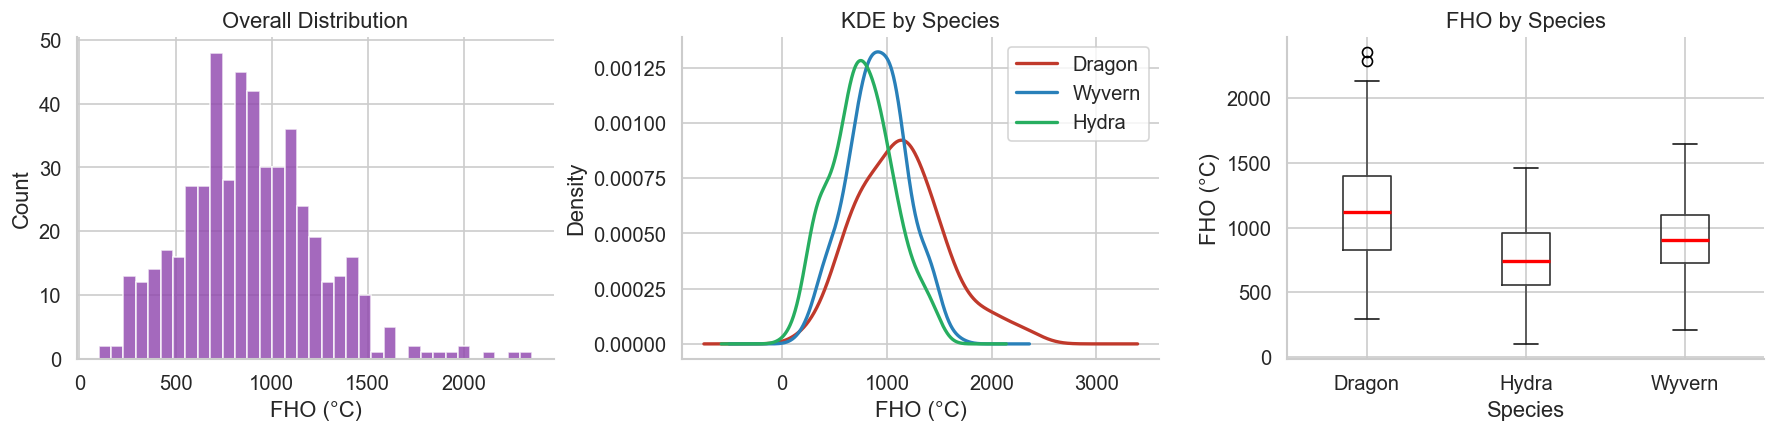

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("FHO Distribution", fontsize=13, fontweight="bold")

# Overall histogram
axes[0].hist(df["FHO"], bins=35, color="#8e44ad", alpha=0.8, edgecolor="white")
axes[0].set_xlabel("FHO (°C)"); axes[0].set_ylabel("Count")
axes[0].set_title("Overall Distribution")

# By species
for spc, col in PALETTE.items():
    sub = df[df["SPC"] == spc]["FHO"]
    sub.plot.kde(ax=axes[1], color=col, lw=2, label=spc)
axes[1].set_xlabel("FHO (°C)"); axes[1].set_title("KDE by Species")
axes[1].legend()

# Box plot by species
df.boxplot(column="FHO", by="SPC", ax=axes[2],
           boxprops=dict(color="#333"),
           medianprops=dict(color="red", lw=2))
axes[2].set_title("FHO by Species")
axes[2].set_xlabel("Species"); axes[2].set_ylabel("FHO (°C)")
plt.suptitle("")

plt.tight_layout()
plt.show()

In [10]:
print("=== FHO mean by species ===")
print(df.groupby("SPC")["FHO"].agg(["mean","median","std"]).round(1))

=== FHO mean by species ===
          mean  median    std
SPC                          
Dragon  1136.8  1123.0  423.0
Hydra    764.0   741.0  297.6
Wyvern   909.2   905.0  282.7


## Species — Physical Characteristics

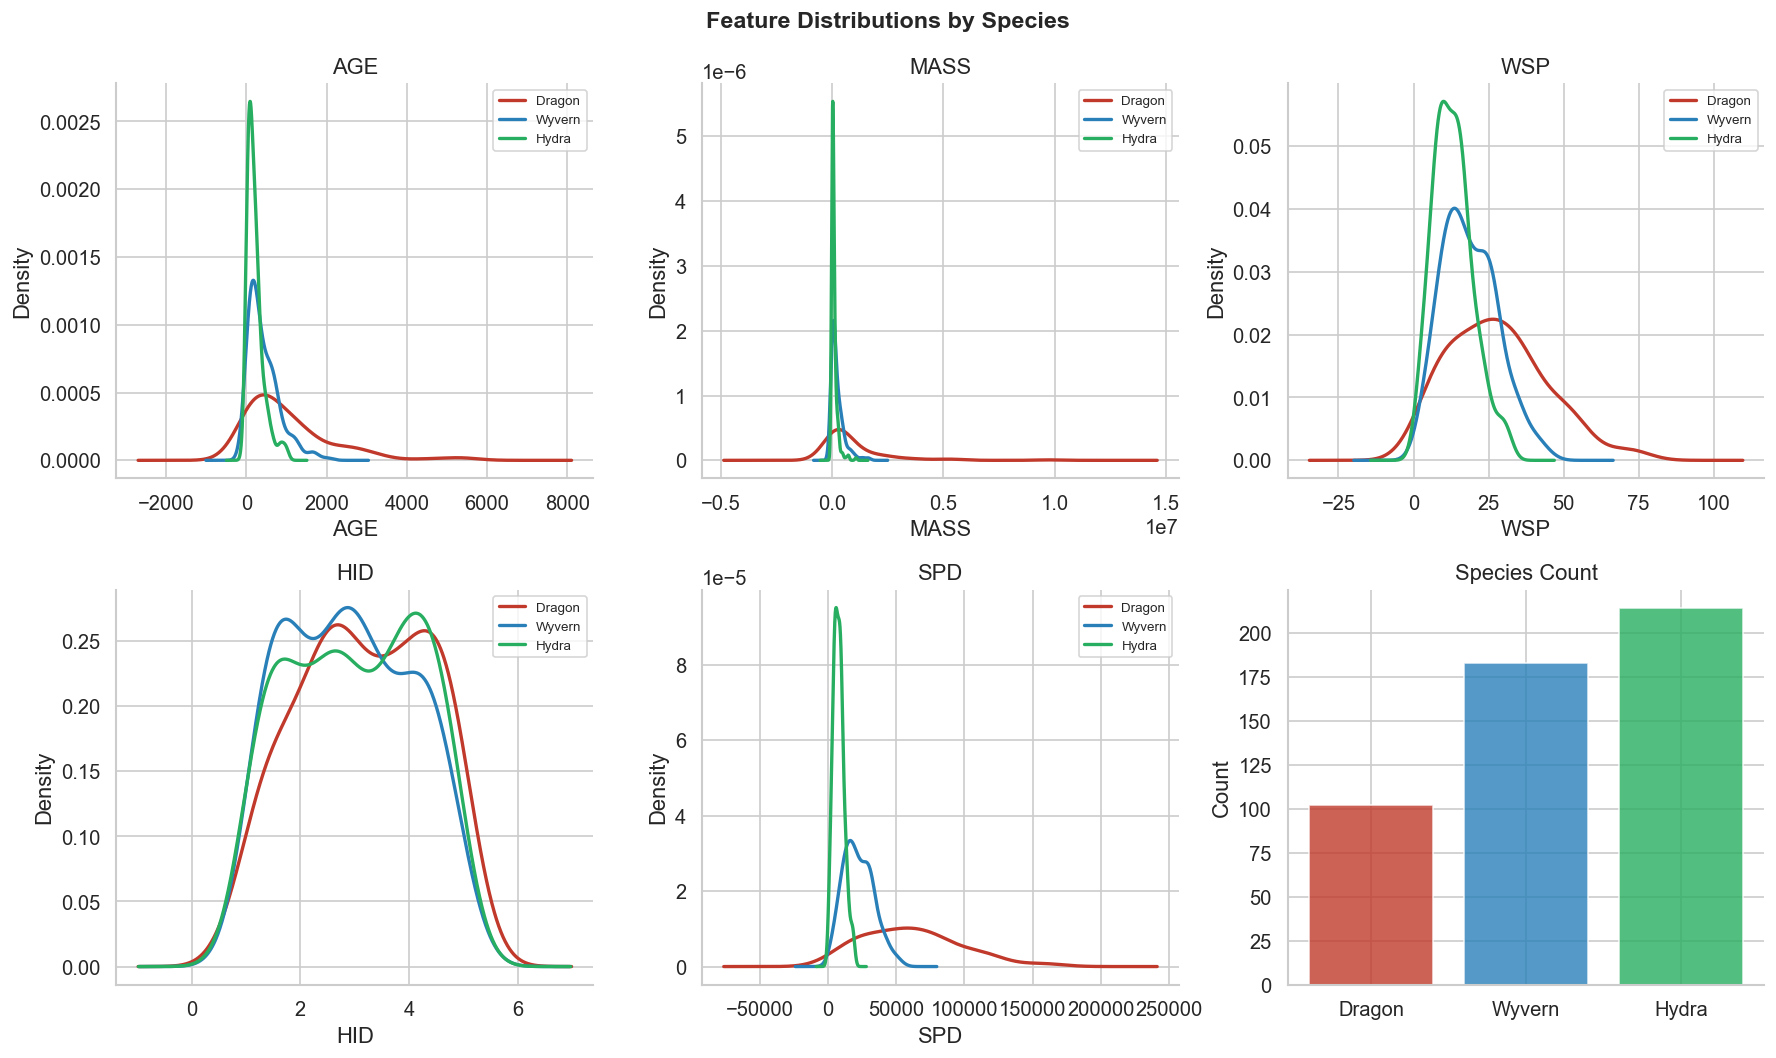

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle("Feature Distributions by Species", fontsize=14, fontweight="bold")

features = ["AGE", "MASS", "WSP", "HID", "SPD"]
for ax, feat in zip(axes.flat, features):
    for spc, col in PALETTE.items():
        df[df["SPC"] == spc][feat].plot.kde(ax=ax, color=col, lw=2, label=spc)
    ax.set_title(feat); ax.set_xlabel(feat); ax.legend(fontsize=8)

# Species count bar
axes[1][2].bar(PALETTE.keys(), [len(df[df["SPC"]==s]) for s in PALETTE],
               color=list(PALETTE.values()), alpha=0.8, edgecolor="white")
axes[1][2].set_title("Species Count"); axes[1][2].set_ylabel("Count")

plt.tight_layout()
plt.show()

## Correlation Matrix

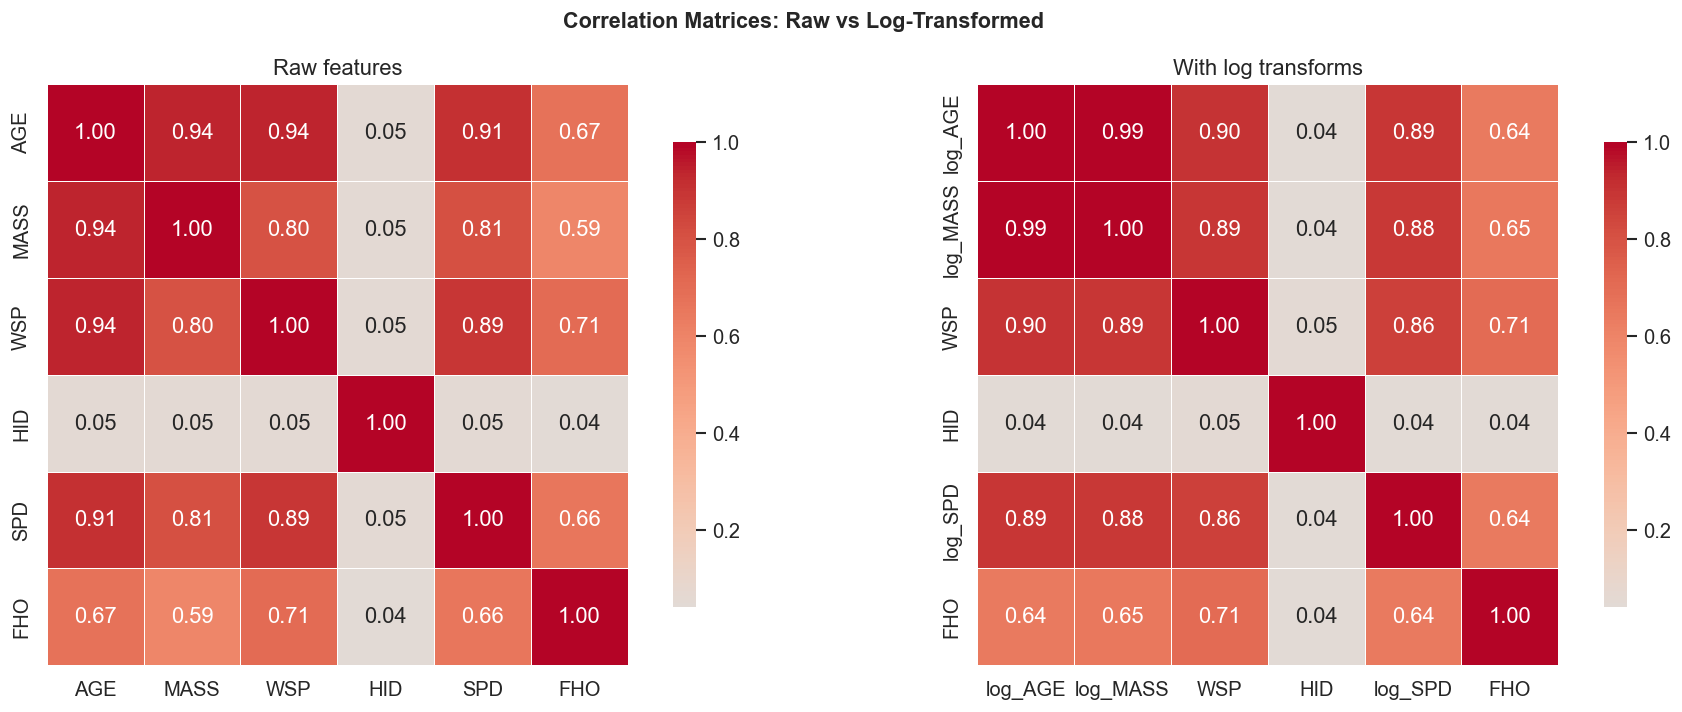

In [12]:
corr_df = df[["AGE","MASS","WSP","HID","SPD","FHO"]].copy()
corr_df["log_AGE"]  = np.log1p(df["AGE"])
corr_df["log_MASS"] = np.log1p(df["MASS"])
corr_df["log_SPD"]  = np.log1p(df["SPD"])

corr = corr_df.corr().round(2)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Correlation Matrices: Raw vs Log-Transformed", fontsize=13, fontweight="bold")

raw_cols = ["AGE","MASS","WSP","HID","SPD","FHO"]
log_cols = ["log_AGE","log_MASS","WSP","HID","log_SPD","FHO"]

for ax, cols, title in zip(axes, [raw_cols, log_cols], ["Raw features", "With log transforms"]):
    sns.heatmap(corr.loc[cols, cols], annot=True, fmt=".2f", cmap="coolwarm",
                center=0, square=True, ax=ax, linewidths=0.5,
                cbar_kws={"shrink": 0.8})
    ax.set_title(title)

plt.tight_layout()
plt.show()

## Outlier Analysis

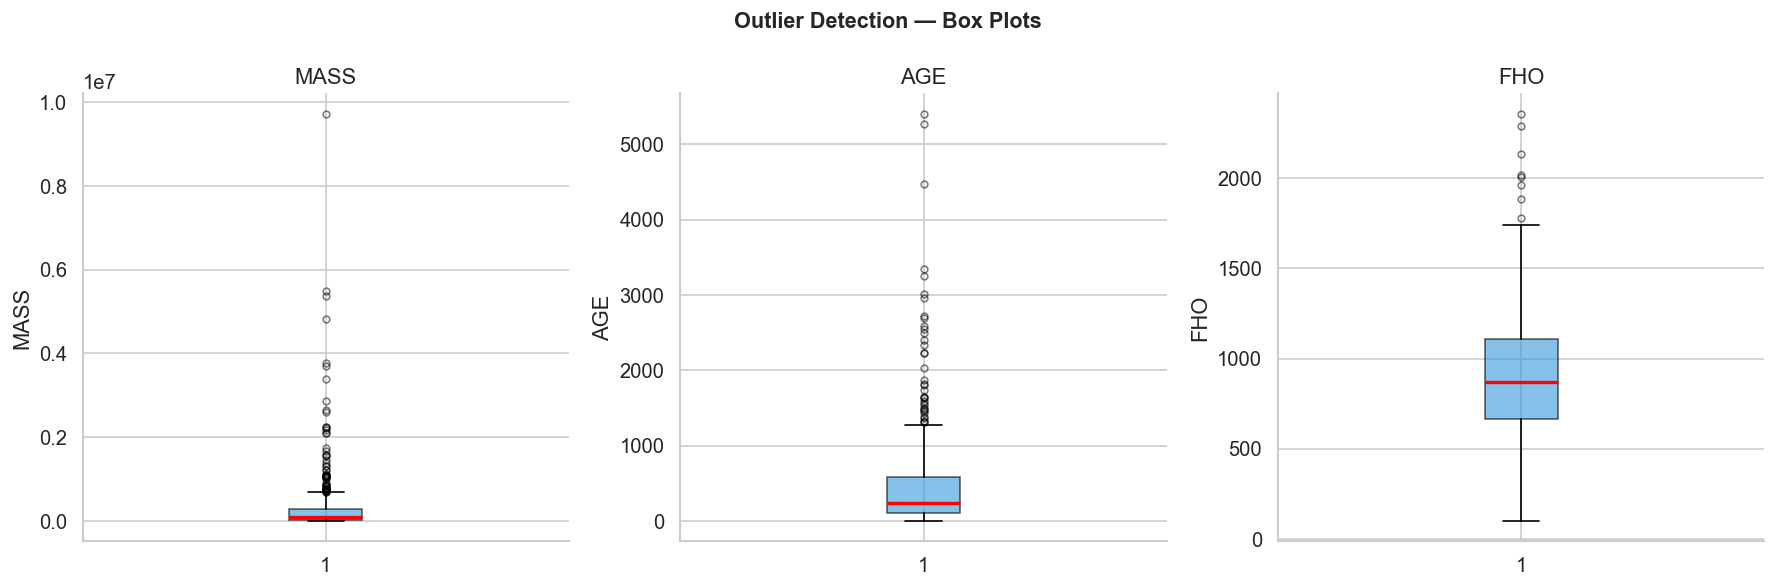

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Outlier Detection — Box Plots", fontsize=13, fontweight="bold")

for ax, col in zip(axes, ["MASS", "AGE", "FHO"]):
    ax.boxplot(df[col], vert=True, patch_artist=True,
               boxprops=dict(facecolor="#3498db", alpha=0.6),
               medianprops=dict(color="red", lw=2),
               flierprops=dict(marker="o", markersize=4, alpha=0.5, color="#e74c3c"))
    ax.set_title(col); ax.set_ylabel(col)

plt.tight_layout()
plt.show()

In [14]:
# Z-score outliers in FHO
z_scores = np.abs(stats.zscore(df["FHO"]))
outliers = df[z_scores > 3]
print(f"FHO outliers (|z| > 3): {len(outliers)}")
print(outliers[["SPC","AGE","MASS","WSP","FHO"]])

FHO outliers (|z| > 3): 6
        SPC   AGE     MASS   WSP   FHO
1    Dragon  2726  3693174  52.0  1960
160  Dragon  5407  5374972  73.6  2132
169  Dragon  2492  2214540  49.8  2009
205  Dragon  4475  5486433  67.0  2288
351  Dragon  3345  3760660  57.8  2358
455  Dragon  5263  9729833  72.8  2019


# Multicollinearity Check

High correlation between predictors (multicollinearity) can destabilise coefficients. We check this with Variance Inflation Factor (VIF).

In [15]:
from sklearn.linear_model import LinearRegression

def vif(X_df):
    """Manual VIF: for each feature, regress it on all others and compute 1/(1-R²)."""
    vifs = []
    cols = list(X_df.columns)
    for i, col in enumerate(cols):
        others = [c for c in cols if c != col]
        m = LinearRegression()
        m.fit(X_df[others], X_df[col])
        r2 = m.score(X_df[others], X_df[col])
        vifs.append({"Feature": col, "VIF": round(1 / (1 - r2 + 1e-10), 2)})
    return pd.DataFrame(vifs).sort_values("VIF", ascending=False)

vif_df = df[["WSP","MASS","AGE","HID","SPD"]].copy()
vif_df["log_MASS"] = np.log1p(df["MASS"])
vif_df["log_AGE"]  = np.log1p(df["AGE"])
vif_df["log_SPD"]  = np.log1p(df["SPD"])

for label, feats in [
    ("Raw",             ["AGE","MASS","WSP","HID","SPD"]),
    ("Log-transformed", ["log_AGE","log_MASS","WSP","HID","log_SPD"]),
]:
    print(f"=== VIF ({label}) ===")
    print(vif(vif_df[feats]).to_string(index=False))
    print()


=== VIF (Raw) ===
Feature   VIF
    AGE 45.37
    WSP 14.56
   MASS 13.89
    SPD  6.42
    HID  1.00

=== VIF (Log-transformed) ===
 Feature    VIF
 log_AGE 120.75
log_MASS 101.84
     WSP   6.32
 log_SPD   5.16
     HID   1.00



Several predictors have high VIF values, especially AGE, WSP, MASS, and SPD. This suggests multicollinearity, meaning these variables share similar information. This may explain why multiple regression only slightly improves on the WSP-only model.

## Key EDA Findings

| Finding | Implication |
|---------|-------------|
| The dataset contained no missing values, but one invalid negative AGE value and one species typo were found. | The negative AGE row was removed and “Wyvernn” was corrected to “Wyvern”. |
| MASS is highly right-skewed, while AGE and SPD are also right-skewed. | Transformations such as logarithms may be useful later during feature engineering. |
| WSP has the strongest linear correlation with FHO. | WSP is expected to be one of the strongest predictors in the regression models. |
| Dragons have the highest median FHO, followed by Wyverns and Hydras. | Species may contain useful information for predicting FHO. |
| AGE, MASS, WSP, and SPD are strongly correlated with one another. | Multicollinearity may explain why adding many variables only slightly improves model performance. |
| HID has near-zero correlation with FHO. | HID is expected to be a weak individual predictor. |
| Several high-FHO outliers were found, mostly among Dragons. | These were kept because they appear biologically plausible rather than clear data errors. |

# 1. Single Variable Regression

Single-variable regression models were manually implemented in Excel for AGE, MASS, WSP, and SPC. The dataset was divided into training and test sets using the script `excel_section1_spc/split.py`, while SPC was encoded into numerical dummy variables before modelling. For each model, the regression coefficients were estimated using the training set, predictions were generated, and residuals and training (R^2) values were calculated. The fitted models were then applied to the test set to calculate test (R^2) and assess generalisation. The results are summarised in the table below.
The corresponding Excel regression models for AGE, MASS, and WSP are provided in the `excel_section1` folder, while the SPC regression model is provided separately in the `excel_section1_spc` folder.

| Model | Train R² | Test R² | Train R² - Test R² | Overfitting? |
|---|---:|---:|---:|---|
| AGE | 0.449431 | 0.456970 | -0.007539 | No |
| MASS | 0.342505 | 0.324903 | 0.017602 | No |
| WSP | 0.500862 | 0.524883 | -0.024021 | No |
| SPC | 0.172203 | 0.089069 | 0.083134  | No |


The WSP model produced the highest test \(R^2\) value of 0.524883, making it the strongest single-variable numerical predictor of FHO among AGE, SPC, MASS, and WSP. The SPC model and AGE model performed moderately, while MASS had the weakest test performance.

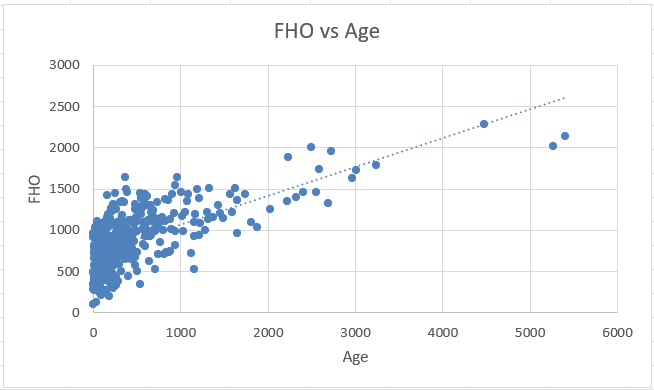

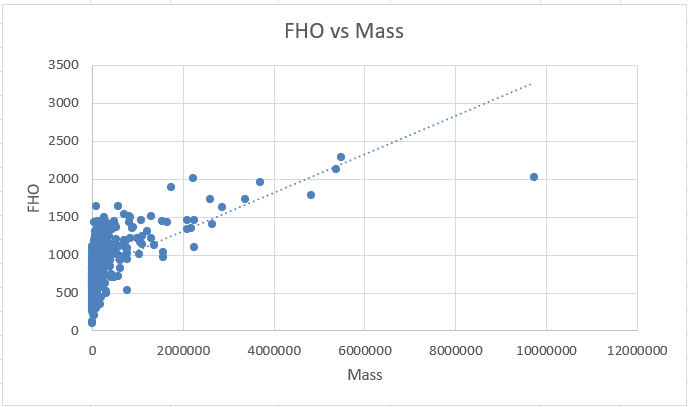

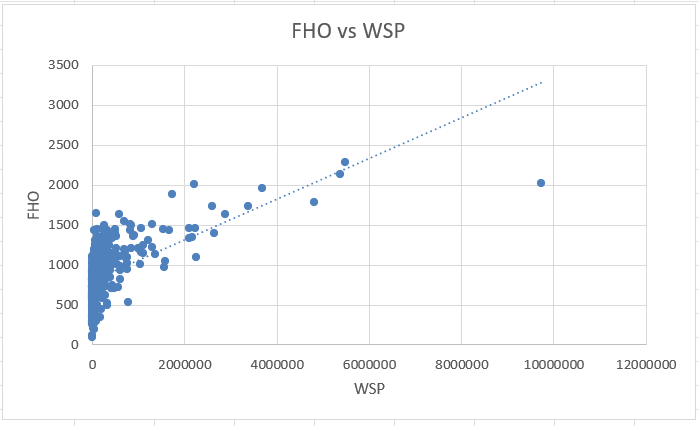

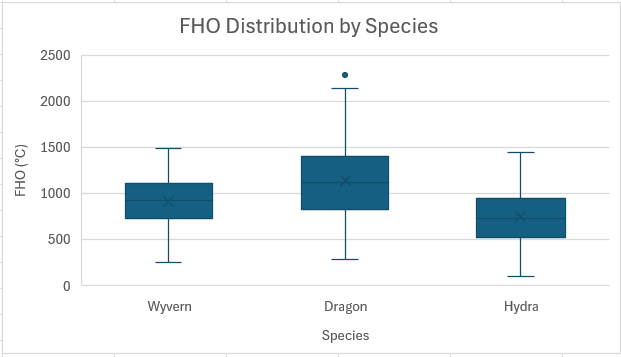

In [1]:
from IPython.display import Image, display

# Display exported Excel plots
image_files = [
    "excel_section1/FHOvsAge.png",
    "excel_section1/FHOvsMass.png",
    "excel_section1/FHOvsWSP.png",
    "excel_section1_spc/FHODistributionBySpecies.png"
]

for image_file in image_files:
    display(Image(filename=image_file))

The plots show positive relationships between FHO and AGE, MASS, and WSP, although the observations are widely dispersed and several extreme values are present. WSP appears to have the clearest relationship with FHO, supporting its position as the strongest numerical single-variable predictor, while MASS shows the weakest individual performance. The species boxplot also shows differences in FHO across species, with Dragons generally producing the highest flame heat output, followed by Wyverns and Hydras.


# 2. Multiple Variable Regression

Multiple linear regression models were built to investigate whether combinations of dragon characteristics improved prediction of Flame Heat Output (FHO) compared with the single-variable models. The predictor variables considered were AGE, MASS, WSP, HID, SPD, and SPC. Since SPC is categorical, it was one-hot encoded before modelling.

Several feature subsets were tested, including size-related models, species-based models, behavioural models, and ablation models where one variable was removed at a time. This allowed us to compare whether adding variables improved model performance and whether any variables were especially important for predicting FHO.

In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler

# Create a separate modelling dataframe so the original EDA dataframe is preserved
model_df = df.copy()

# One-hot encode the categorical species variable
model_df = pd.get_dummies(model_df, columns=["SPC"], dtype=int)

# Target variable
y = model_df["FHO"]

In [17]:
subsets = {
    # Minimal/baseline models
    "WSP only": ["WSP"],
    "AGE, WSP": ["AGE", "WSP"],
    "WSP, MASS": ["WSP", "MASS"],
    "WSP, SPD": ["WSP", "SPD"],

    # Ablation models: remove one variable at a time
    "Drop AGE": ["MASS", "WSP", "HID", "SPD"],
    "Drop MASS": ["AGE", "WSP", "HID", "SPD"],
    "Drop HID": ["AGE", "MASS", "WSP", "SPD"],
    "Drop SPD": ["AGE", "MASS", "WSP", "HID"],
    "Drop WSP": ["AGE", "MASS", "HID", "SPD"],

    # Species-based models
    "WSP, SPC": ["WSP", "SPC_Dragon", "SPC_Hydra", "SPC_Wyvern"],
    "AGE, WSP, SPC": ["AGE", "WSP", "SPC_Dragon", "SPC_Hydra", "SPC_Wyvern"],
    "WSP, MASS, SPC": ["WSP", "MASS", "SPC_Dragon", "SPC_Hydra", "SPC_Wyvern"],
    "WSP, HID, SPC": ["WSP", "HID", "SPC_Dragon", "SPC_Hydra", "SPC_Wyvern"],

    # Physical size models
    "WSP, MASS, HID": ["WSP", "MASS", "HID"],
    "MASS, HID": ["MASS", "HID"],
    "WSP, HID": ["WSP", "HID"],

    # Behavioural/performance models
    "SPD only": ["SPD"],
    "AGE, SPD": ["AGE", "SPD"],
    "WSP, AGE, SPD": ["WSP", "AGE", "SPD"],

    # Age-focused models
    "AGE only": ["AGE"],
    "AGE, MASS": ["AGE", "MASS"],
    "AGE, HID": ["AGE", "HID"],
    "AGE, MASS, HID": ["AGE", "MASS", "HID"],
}

Several combinations of predictors were tested to determine whether adding variables improved the prediction of FHO. The models included simple baseline combinations, ablation models, species-based models, physical-size models, behavioural models, and age-focused models.

The baseline models, such as WSP only, AGE and WSP, WSP and MASS, and WSP and SPD, were used to compare whether adding one additional predictor improved on the strongest single-variable model. The ablation models, such as Drop AGE, Drop MASS, Drop HID, Drop SPD, and Drop WSP, were used to test the importance of each variable by removing one predictor at a time. This helped identify which variables contributed the most to model performance.

Species-based models were also tested by including one-hot encoded SPC variables. These models were used to check whether species added useful predictive information beyond physical characteristics such as WSP and MASS. Physical-size models were tested because variables such as WSP, MASS, and HID are all related to dragon size and body structure. Behavioural models involving SPD were tested because sustained flight speed may reflect dragon strength or energy output. Age-focused models were included because older dragons may be more mature and may therefore produce stronger flame heat output.

In [18]:
def run_models(subsets_dict):
    results = []

    for name, features in subsets_dict.items():
        X = model_df[features]

        # split into train and test sets
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42
        )

        # Scale features after splitting to avoid data leakage
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        model = LinearRegression()
        model.fit(X_train_scaled, y_train)

        train_pred = model.predict(X_train_scaled)
        test_pred = model.predict(X_test_scaled)

        train_r2 = r2_score(y_train, train_pred)
        test_r2 = r2_score(y_test, test_pred)
        rmse = np.sqrt(mean_squared_error(y_test, test_pred))

        results.append({
            "Model": name,
            "Features": ", ".join(features),
            "Train R²": train_r2,
            "Test R²": test_r2,
            "RMSE": rmse,
            "Train R² - Test R²": train_r2 - test_r2
        })

    return pd.DataFrame(results)

multi_results = run_models(subsets)

multi_results = multi_results.sort_values(
    by=["Test R²", "RMSE"],
    ascending=[False, True]
)

multi_results

,Model,Features,Train R²,Test R²,RMSE,Train R² - Test R²
7,Drop SPD,"AGE, MASS, WSP, HID",0.502289,0.525655,236.973039,-0.023366
2,"WSP, MASS","WSP, MASS",0.501850,0.525278,237.067059,-0.023428
0,WSP only,WSP,0.500862,0.524883,237.165684,-0.024021
1,"AGE, WSP","AGE, WSP",0.501235,0.524708,237.209569,-0.023472
13,"WSP, MASS, HID","WSP, MASS, HID",0.501934,0.524618,237.231971,-0.022684
6,Drop HID,"AGE, MASS, WSP, SPD",0.505706,0.524550,237.248877,-0.018844
15,"WSP, HID","WSP, HID",0.500948,0.524253,237.323033,-0.023305
3,"WSP, SPD","WSP, SPD",0.504464,0.522219,237.829730,-0.017755
18,"WSP, AGE, SPD","WSP, AGE, SPD",0.504563,0.522021,237.879104,-0.017457
9,"WSP, SPC","WSP, SPC_Dragon, SPC_Hydra, SPC_Wyvern",0.506580,0.521898,237.909642,-0.015318


The best-performing raw multiple regression model was the Drop SPD model, which used AGE, MASS, WSP, and HID as predictors. This model achieved the highest test \(R^2\) and the lowest RMSE among the pre-transformation multiple regression models.

# 3. Model Comparison

The main pattern across the models is that performance improves only marginally when moving from the best single-variable model to the best raw multiple-variable model. The WSP-only model already explained a large portion of the variation in FHO, and adding AGE, MASS, and HID produced only a very small improvement in test performance. This suggests that the additional variables provide overlapping information rather than new value.

Since WSP is strongly related to dragon size and physical development, it likely captures much of the same information contained in variables such as MASS and AGE. The poorer performance of the Drop WSP model further confirms that wingspan is one of the most important predictors in the dataset.

The models also showed no strong evidence of overfitting, as the training and test (R^2) values remained close across the main models. The Drop SPD model is recommended as the best raw multiple regression model because it achieved the strongest test performance, but the WSP-only model remains an important baseline because it performs almost as well with far fewer predictors.


# 4. Interpretability



In [21]:
# Interpretability for preferred raw model: Drop SPD
# Features: AGE, MASS, WSP, HID

preferred_features = ["AGE", "MASS", "WSP", "HID"]

X = model_df[preferred_features]
y = model_df["FHO"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_scaled, y_train  )

coefficients = pd.DataFrame({
    "Feature": preferred_features,
    "Coefficient": model.coef_.round(3),
    "Abs Coef": np.abs(model.coef_).round(3)
})

coefficients = coefficients.sort_values("Abs Coef", ascending=False).drop(columns="Abs Coef")
coefficients

,Feature,Coefficient
2,WSP,255.522
0,AGE,-41.695
1,MASS,39.862
3,HID,3.178


The signs of the coefficients mostly make sense. WSP and MASS have positive coefficients, meaning that dragons with larger wingspans and greater mass are predicted to have higher FHO when the other variables are held constant. This is reasonable because both features are linked to body size, strength, and possible flame-producing capacity. HID has a very small positive coefficient, suggesting that hide thickness has little effect on FHO in this model.

The coefficient magnitudes show that WSP has the strongest influence on predicted FHO, since it has the largest absolute coefficient. This supports the earlier model comparison, where removing WSP caused a clear drop in performance. MASS has a smaller influence, while HID has the weakest effect, meaning that wingspan is the dominant predictor in the preferred model.

The most surprising result is AGE, because its coefficient is negative. Biologically, older dragons might be expected to produce hotter flames due to maturity. However, this may be caused by multicollinearity, since AGE, MASS, and WSP are related to dragon development. Once WSP and MASS are included, AGE may no longer add independent positive information, so the negative coefficient should not be interpreted as older dragons naturally having weaker flames.


# 5. Model Evaluation

In [23]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import cross_val_score, KFold
from sklearn.pipeline import make_pipeline

# Predictions
train_pred = model.predict(X_train_scaled)
test_pred = model.predict(X_test_scaled)

# Residuals
residuals = y_test - test_pred

# Evaluation metrics
train_r2 = r2_score(y_train, train_pred)
test_r2 = r2_score(y_test, test_pred)
rmse = np.sqrt(mean_squared_error(y_test, test_pred))
mae = mean_absolute_error(y_test, test_pred)

print(f"Training R²: {train_r2:.4f}")
print(f"Test R²: {test_r2:.4f}")
print(f"Test RMSE: {rmse:.2f}")
print(f"Test MAE: {mae:.2f}")

Training R²: 0.5023
Test R²: 0.5257
Test RMSE: 236.97
Test MAE: 190.36


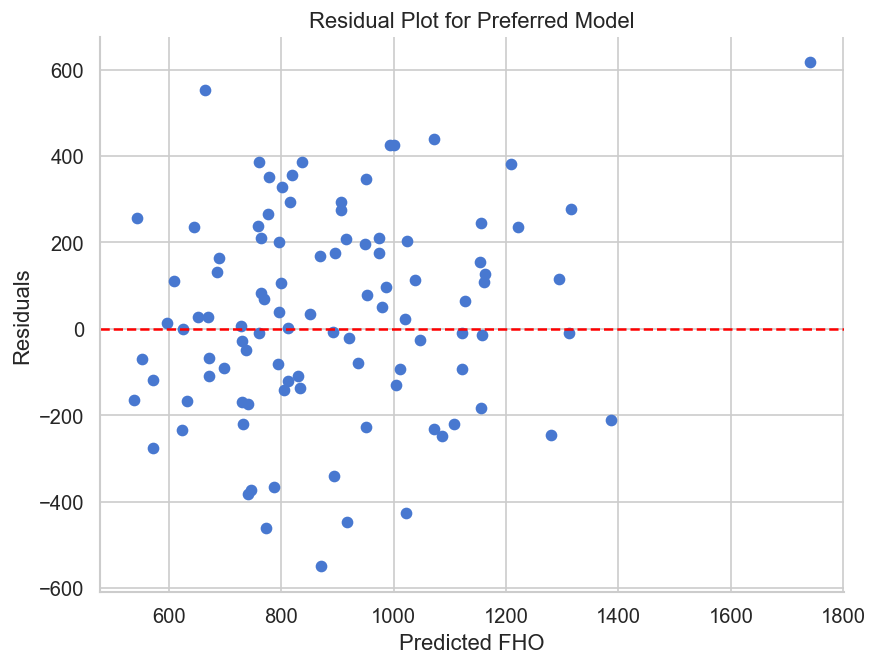

In [24]:
# Residual plots
plt.figure(figsize=(8, 6))
plt.scatter(test_pred, residuals)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted FHO")
plt.ylabel("Residuals")
plt.title("Residual Plot for Preferred Model")
plt.show()

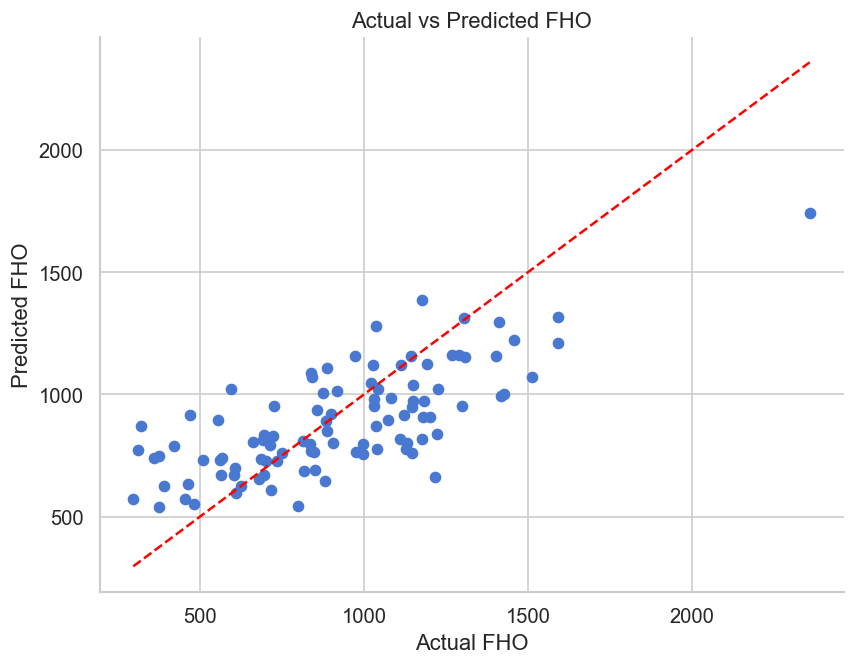

In [25]:
# Actual vs predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, test_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red", linestyle="--")
plt.xlabel("Actual FHO")
plt.ylabel("Predicted FHO")
plt.title("Actual vs Predicted FHO")
plt.show()

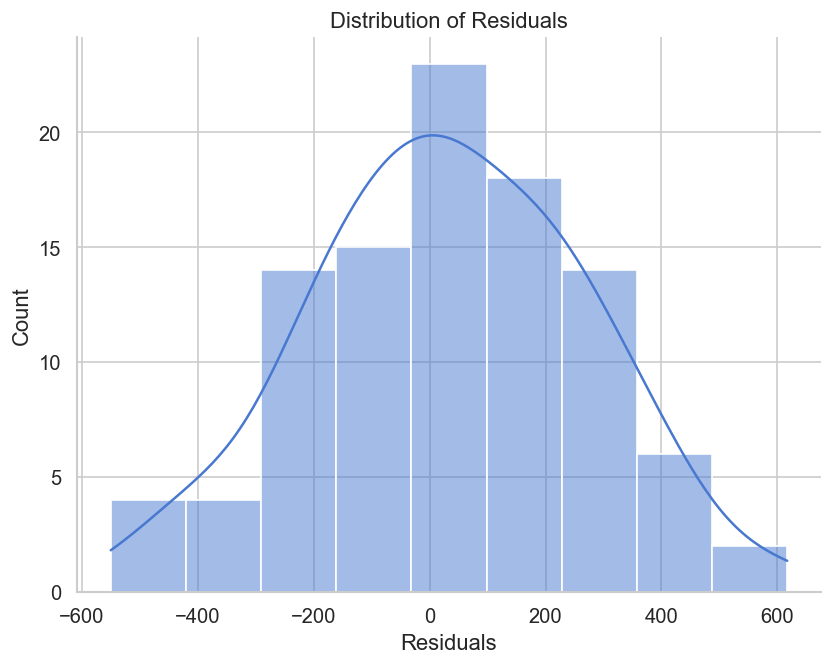

In [26]:
# Residual distribution
plt.figure(figsize=(8, 6))
sns.histplot(residuals, kde=True)
plt.xlabel("Residuals")
plt.title("Distribution of Residuals")
plt.show()

In [27]:
# Cross-validation for preferred model  

from sklearn.model_selection import cross_val_score, KFold
from sklearn.pipeline import make_pipeline

pipeline = make_pipeline(StandardScaler(), LinearRegression())

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_r2_scores = cross_val_score(pipeline, X, y, cv=kf, scoring="r2")

cv_rmse_scores = -cross_val_score(pipeline, X, y, cv=kf, scoring="neg_root_mean_squared_error")

print(f"Cross-validated R² scores: {cv_r2_scores.round(4)}")
print(f"Mean CV R²: {cv_r2_scores.mean():.4f}")
print(f"Standard deviation of CV R²: {cv_r2_scores.std():.4f}")

print(f"Cross-validated RMSE scores: {cv_rmse_scores.round(2)}")
print(f"Mean CV RMSE: {cv_rmse_scores.mean():.2f}")
print(f"Standard deviation of CV RMSE: {cv_rmse_scores.std():.2f}" )



Cross-validated R² scores: [0.5257 0.5233 0.3428 0.3799 0.4611]
Mean CV R²: 0.4466
Standard deviation of CV R²: 0.0743
Cross-validated RMSE scores: [236.97 220.28 260.43 230.98 326.96]
Mean CV RMSE: 255.12
Standard deviation of CV RMSE: 38.25


The preferred raw model was evaluated using residual plots, an actual-versus-predicted plot, and the distribution of residuals. The residual plot shows that the errors are mostly scattered around the zero line, which suggests that the model does not have a strong systematic bias. However, there are several large positive and negative residuals, especially for higher predicted FHO values, showing that the model still struggles with some extreme flame heat outputs.

The actual-versus-predicted plot shows a clear positive relationship between the true and predicted FHO values, meaning the model captures the general trend in the data. However, many points are still spread away from the diagonal line. This confirms that the model has moderate predictive ability rather than highly accurate predictions. The model appears to underpredict some high-FHO dragons and overpredict some lower-FHO dragons.

The residual distribution is roughly centred around zero and has an approximately bell-shaped form, which supports the use of a linear regression model. However, the spread of residuals shows that there is still unexplained variation in FHO. This may be due to environmental variation, measurement noise, or biological factors not included in the dataset. Overall, the model generalises well, but its predictive accuracy remains limited.

# 6. Feature Engineering

In [32]:
# Feature engineering
model_df["log_MASS"] = np.log1p(model_df["MASS"])
model_df["log_AGE"] = np.log1p(model_df["AGE"])
model_df["log_SPD"] = np.log1p(model_df["SPD"])
model_df["sqrt_WSP"] = np.sqrt(model_df["WSP"])

# Interaction term between maturity and size
model_df["AGE_x_WSP"] = model_df["log_AGE"] * model_df["sqrt_WSP"]

# Combined physical size
model_df["WSP_x_MASS"] = model_df["sqrt_WSP"] * model_df["log_MASS"]

# Body-density proxy
model_df["mass_per_wsp"] = model_df["log_MASS"] / (model_df["WSP"] + 1)

In [33]:
post_subsets = {
    # Transformed feature models
    "Log transforms only": [
        "log_AGE", "log_MASS", "sqrt_WSP",
        "HID", "log_SPD",
        "SPC_Dragon", "SPC_Hydra", "SPC_Wyvern"
    ],

    "Log + AGE interaction": [
        "log_AGE", "log_MASS", "sqrt_WSP",
        "HID", "log_SPD", "AGE_x_WSP",
        "SPC_Dragon", "SPC_Hydra", "SPC_Wyvern"
    ],

    "Log + AGE interaction + density": [
        "log_AGE", "log_MASS", "sqrt_WSP",
        "HID", "log_SPD", "AGE_x_WSP",
        "mass_per_wsp",
        "SPC_Dragon", "SPC_Hydra", "SPC_Wyvern"
    ],

    "Log + AGE interaction + size interaction": [
        "log_AGE", "log_MASS", "sqrt_WSP",
        "HID", "log_SPD", "AGE_x_WSP", "WSP_x_MASS",
        "SPC_Dragon", "SPC_Hydra", "SPC_Wyvern"
    ],

    "Log + all engineered features": [
        "log_AGE", "log_MASS", "sqrt_WSP",
        "HID", "log_SPD", "AGE_x_WSP",
        "WSP_x_MASS", "mass_per_wsp",
        "SPC_Dragon", "SPC_Hydra", "SPC_Wyvern"
    ],

    "Log, no SPC": [
        "log_AGE", "log_MASS", "sqrt_WSP",
        "HID", "log_SPD", "AGE_x_WSP", "WSP_x_MASS"
    ],
}


In [34]:
multi_results = run_models(post_subsets)

multi_results = multi_results.sort_values(
    by=["Test R²", "RMSE"],
    ascending=[False, True]
)

multi_results_display = multi_results.copy()
multi_results_display["Train R²"] = multi_results_display["Train R²"].round(4)
multi_results_display["Test R²"] = multi_results_display["Test R²"].round(4)
multi_results_display["RMSE"] = multi_results_display["RMSE"].round(1)
multi_results_display["Train R² - Test R²"] = multi_results_display["Train R² - Test R²"].round(4)

multi_results_display

,Model,Features,Train R²,Test R²,RMSE,Train R² - Test R²
3,Log + AGE interaction + size interaction,"log_AGE, log_MASS, sqrt_WSP, HID, log_SPD, AGE...",0.5178,0.5523,230.2,-0.0345
4,Log + all engineered features,"log_AGE, log_MASS, sqrt_WSP, HID, log_SPD, AGE...",0.5178,0.5523,230.2,-0.0345
1,Log + AGE interaction,"log_AGE, log_MASS, sqrt_WSP, HID, log_SPD, AGE...",0.5177,0.5523,230.2,-0.0346
2,Log + AGE interaction + density,"log_AGE, log_MASS, sqrt_WSP, HID, log_SPD, AGE...",0.5177,0.5522,230.2,-0.0345
5,"Log, no SPC","log_AGE, log_MASS, sqrt_WSP, HID, log_SPD, AGE...",0.5177,0.5520,230.3,-0.0342
0,Log transforms only,"log_AGE, log_MASS, sqrt_WSP, HID, log_SPD, SPC...",0.5147,0.5496,230.9,-0.0350


Feature engineering was used to test whether transformed variables and interaction terms could improve the regression model. Since the EDA showed that some predictors were right-skewed, logarithmic transformations were applied to AGE, MASS, and SPD. A square-root transformation was also applied to WSP, since wingspan was the strongest predictor and its relationship with FHO may not be perfectly linear.

Interaction terms were created to capture combined biological effects. The AGE × WSP feature represents the combined effect of maturity and body size, while WSP × MASS represents overall physical size. A mass-per-wingspan feature was also tested as a rough body-density proxy.

The engineered models improved performance compared with the best raw model. The best raw model had a test (R^2) of 0.5257 and an RMSE of 237.0, while the best engineered models achieved a test (R^2) of about 0.5523 and an RMSE of about 230.2. The best results came from the models including log transformations and interaction terms. However, adding all engineered features did not meaningfully improve performance beyond the simpler interaction model, so the improvement appears to come mainly from the transformations and the AGE × WSP / WSP × MASS interaction structure.


# Conclusion

This project developed and compared regression models for predicting dragon Flame Heat Output using AGE, MASS, WSP, HID, SPD, and SPC. The exploratory analysis showed that WSP had the strongest relationship with FHO, while HID and SPC provided relatively little predictive information on their own. Several physical predictors were also highly correlated, indicating multicollinearity and explaining why adding more raw variables produced only a small improvement over the WSP-only model.

Among the raw models, the AGE, MASS, WSP, and HID model achieved the best test performance, with a test (R^2) of 0.5257 and an RMSE of 237.0. Its coefficients confirmed that WSP was the dominant predictor, while the negative AGE coefficient was likely influenced by multicollinearity with other size-related variables. Residual analysis showed no strong systematic bias, although the model struggled with some extreme FHO values. Cross-validation also showed that performance varied across data splits, indicating moderate rather than highly reliable predictive ability.

Feature engineering produced a modest improvement. Models using logarithmic and square-root transformations together with interaction terms achieved a test (R^2) of approximately 0.5523 and an RMSE of 230.2. Overall, the engineered interaction model is recommended because it provided the strongest test performance, although approximately 45% of the variation in FHO remains unexplained. This suggests that additional biological, environmental, or magical characteristics may be required to produce substantially more accurate predictions.
